## Explaination

N = 4 means each $\hat{\lambda}$ will be 4 components wide.
L = 4 means between max-obf $\hat{\lambda} : \lambda_i = \frac{1}{N}$ and no-mixup $\hat{\lambda} : \lambda_i = 1\{i = 0\}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

[0.5        0.33333333 0.16666667 0.        ]
[0.4375 0.3125 0.1875 0.0625]
[0.375      0.29166667 0.20833333 0.125     ]
[0.3125     0.27083333 0.22916667 0.1875    ]


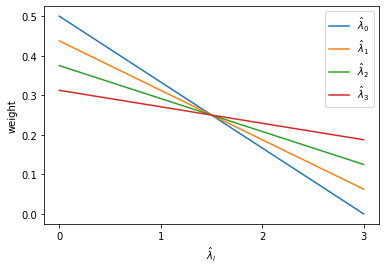

In [2]:

N = 4
L = 4
LAMBDAS = [np.interp(np.linspace(0., 1., N), [0., 1.], [lam, 1-lam]) for lam in np.linspace(1., .5, L+1)]
LAMBDAS = [l/l.sum() for l in LAMBDAS]
# remove flat
LAMBDAS = LAMBDAS[:-1]

for i, l in enumerate(LAMBDAS):
    print(l)
    plt.plot(l, label="$\hat{\lambda}_"+str(i)+"$")
plt.xticks([0, 1, 2, 3])
plt.xlabel("$\hat{\lambda}_i$")
plt.ylabel("weight")
plt.legend()
plt.savefig("lambda_linear.pdf")

[8.33440514e-01 1.38906752e-01 2.31511254e-02 3.85852090e-03
 6.43086817e-04]
[0.78980031 0.16627375 0.035005   0.00736947 0.00155147]
[0.71564829 0.20447094 0.05842027 0.01669151 0.004769  ]
[0.56535976 0.251271   0.111676   0.04963378 0.02205946]


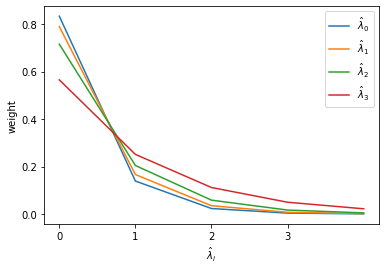

In [3]:
N = 5
L = 4
# inv pow law lambdas
# 5 lambdas
#LAMBDAS = [np.array([1/(x**n) for n in range(N)]) for x in np.linspace(1., 6., 5)]
# 4 lambdas
LAMBDAS = [np.array([1/(x**n) for n in range(N)]) for x in np.linspace(1., 6., L+1)]
LAMBDAS.reverse()
LAMBDAS = [l/l.sum() for l in LAMBDAS]
# remove flat
LAMBDAS = LAMBDAS[:-1]

for i, l in enumerate(LAMBDAS):
    print(l)
    plt.plot(l, label="$\hat{\lambda}_"+str(i)+"$")
plt.xticks([0, 1, 2, 3])
plt.xlabel("$\hat{\lambda}_i$")
plt.ylabel("weight")
plt.legend()
plt.savefig("lambda_invpow.pdf")

[0.44039854 0.33037818 0.16962182 0.05960146]
[0.4910069  0.39569574 0.10430426 0.0089931 ]
[0.49876369 0.44039854 0.05960146 0.00123631]
[4.99832325e-01 4.67515415e-01 3.24845846e-02 1.67675065e-04]


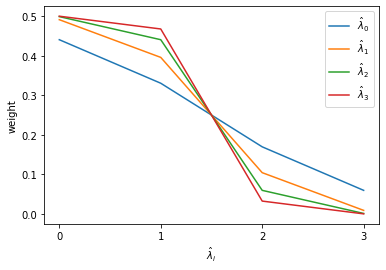

In [4]:
N = 4
L = 4
# sigmoid lambdas
sigmoid = lambda x: 1/(1+np.exp(-x))
lspace = lambda x, N: np.linspace(-x, x, N)
LAMBDAS = [np.array([sigmoid(x) for x in lspace(y*2, N)])[::-1] for y in range(L+1)]
# remove flat
LAMBDAS = LAMBDAS[1:]
LAMBDAS = [l/l.sum() for l in LAMBDAS]

for i, l in enumerate(LAMBDAS):
    print(l)
    plt.plot(l, label="$\hat{\lambda}_"+str(i)+"$")
plt.xticks([0, 1, 2, 3])
plt.xlabel("$\hat{\lambda}_i$")
plt.ylabel("weight")
plt.legend()
plt.savefig("lambda_sigmoid.pdf")

## Sweetspot lambda formula


In [5]:
import numpy as np

N = 4
LAMBDA_SWEETSPOT = np.array([3/(4**(i+1)) for i in range(N-1)] + [.25**(N-1)])
print(LAMBDA_SWEETSPOT, LAMBDA_SWEETSPOT.sum())

[0.75     0.1875   0.046875 0.015625] 1.0


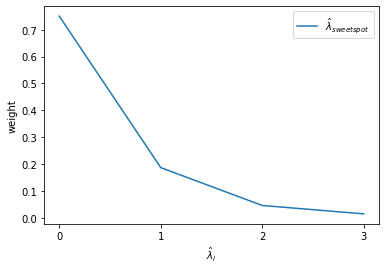

In [6]:

plt.plot(LAMBDA_SWEETSPOT, label="$\hat{\lambda}_{sweetspot}$")
plt.xticks([0, 1, 2, 3])
plt.xlabel("$\hat{\lambda}_i$")
plt.ylabel("weight")
plt.legend()
plt.savefig("lambda_sweetspot.pdf")